# Non-negative K-SVD Unfolding for BNCT

This notebook demonstrates the `unfold_nnksvd` method, implementing the
BNCT epithermal neutron spectrum unfolding approach of
**Xu et al. (NIMA 2026)**,
[DOI:10.1016/j.nima.2026.172070](https://doi.org/10.1016/j.nima.2026.172070).

The pipeline combines:
1. **Non-negative K-SVD dictionary learning** — K-SVD with non-negative
   truncation of dictionary atoms.
2. **Sparse inversion** with three strategies:
   - `nnls_topk` (proposed): global NNLS → top-K screening → local NNLS.
   - `omp`: classic Orthogonal Matching Pursuit.
   - `nn_omp`: OMP with non-negativity constraint.

Three evaluation metrics from the article:
- **Relative flux error** (Eq. 2.7): lower is better.
- **Pearson correlation** (Eq. 2.8): closer to 1 is better.
- **Comprehensive score** (Eq. 2.9): `flux_err - 0.5 * corr`, lower is better.

In [1]:
# %pip install bssunfold pandas numpy matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bssunfold import Detector, RF_GSF
from bssunfold.utils.comparison import (
    compare_spectra,
    relative_flux_error,
    flux_correlation_coefficient,
    comprehensive_score,
)

## 1. Load the detector response functions

We use the GSF response functions (10 spherical detectors, 60 energy bins).
The article uses 10 polyethylene semi-cylindrical spheres with 48 bins,
but the relative behaviour of the three sparse coders is preserved.

Detector grid: 60 bins, 1.0e-09 – 631.0 MeV


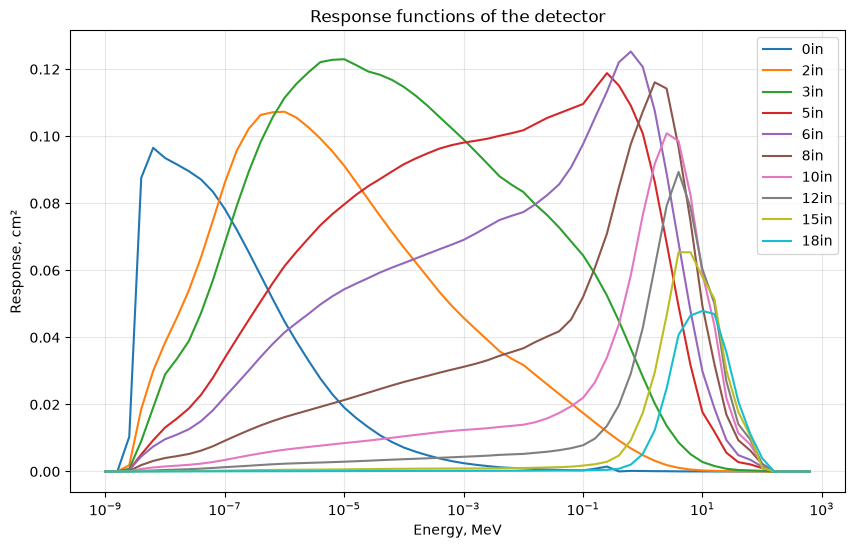

In [3]:
detector = Detector(RF_GSF)
print(f"Detector grid: {detector.n_energy_bins} bins, "
      f"{detector.E_MeV[0]:.1e} – {detector.E_MeV[-1]:.1f} MeV")
detector.plot_response_functions()

## 2. Load IAEA Compendium reference spectrum

Monte Carlo reference spectra from the IAEA Compendium of
neutron spectra for detector response characterization.
We use `t4-14-s.txt_1` (a BNCT-like beam-shaping-assembly spectrum) as
the ground-truth for unfolding.

The CSV energy grid (61 points) differs slightly from the detector grid
(60 points), so we interpolate the reference spectrum to match.

Reference CSV: 61 rows, 20 spectra
Readings: {'0in': 0.06677491401742278, '2in': 0.09010283397418649, '3in': 0.1382263772314859, '5in': 0.16389232289877687, '6in': 0.14070027416577424, '8in': 0.08047235051716813, '10in': 0.039241501396214046, '12in': 0.017890803738592937, '15in': 0.006419245076304746, '18in': 0.0030846997499625454}


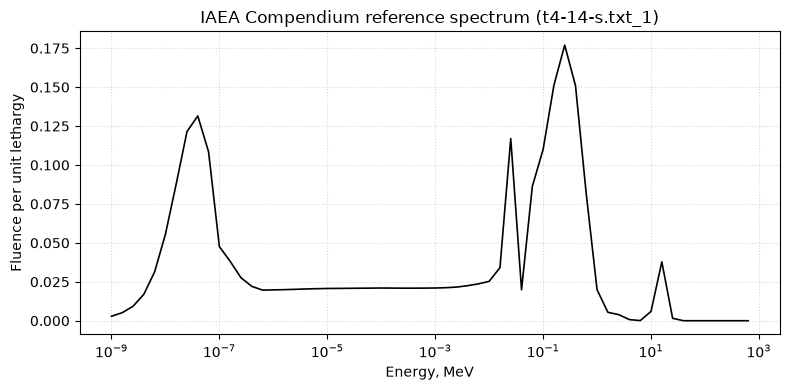

In [4]:
reference_csv = pd.read_csv(
    '../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv'
)
print(f'Reference CSV: {len(reference_csv)} rows, '
      f'{len(reference_csv.columns) - 1} spectra')

# Interpolate to detector energy grid.
phi_true = np.interp(
    detector.E_MeV, reference_csv['E_MeV'].values, reference_csv['t4-14-s.txt_1'].values
)

# Readings via the response matrix (uses internal interpolation).
readings = detector.get_effective_readings_for_spectra(
    reference_csv[['E_MeV', 't4-14-s.txt_1']]
)
print(f'Readings: {readings}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(detector.E_MeV, phi_true, 'k-', linewidth=1.2)
ax.set_xscale('log')
ax.set_xlabel('Energy, MeV')
ax.set_ylabel('Fluence per unit lethargy')
ax.set_title('IAEA Compendium reference spectrum (t4-14-s.txt_1)')
ax.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Compare the three sparse-coding strategies

We use `n_atoms=15`, `sparsity=4` — the article's dictionary size with
sufficient sparsity to represent this 3-component spectrum (thermal +
epithermal + fast).  The article's `sparsity=2` is optimal for their
specific BNCT response matrix; other detectors may need higher K.

In [5]:
coders = ['nnls_topk', 'omp', 'nn_omp']
coder_labels = {'nnls_topk': 'NNLS+TopK (proposed)', 'omp': 'OMP', 'nn_omp': 'NN-OMP'}
colors = {'nnls_topk': '#2196F3', 'omp': '#FF9800', 'nn_omp': '#E91E63'}

results = {}
for coder in coders:
    results[coder] = detector.unfold_nnksvd(
        readings,
        n_atoms=15,
        sparsity=4,
        n_dictionary_iterations=80,
        lambda_tik=0.01,
        prior_wt=0.5,
        sparse_coder=coder,
        random_state=42,
    )

# Metrics table
print(f"{'Method':<22s} {'Flux err':>10s} {'Corr':>10s} {'Score':>10s}")
print('-' * 55)
for coder in coders:
    m = compare_spectra(
        phi_true, results[coder]['spectrum'],
        metrics=['relative_flux_error', 'flux_correlation_coefficient', 'comprehensive_score'],
    )
    print(
        f"{coder_labels[coder]:<22s} "
        f"{m['relative_flux_error']:>10.4f} "
        f"{m['flux_correlation_coefficient']:>10.4f} "
        f"{m['comprehensive_score']:>10.4f}"
    )

Method                   Flux err       Corr      Score
-------------------------------------------------------
NNLS+TopK (proposed)       0.7954     0.7469     0.4220
OMP                        1.2471     0.4880     1.0031
NN-OMP                     1.1010     0.2746     0.9637


## 4. Visual comparison of the unfolded spectra

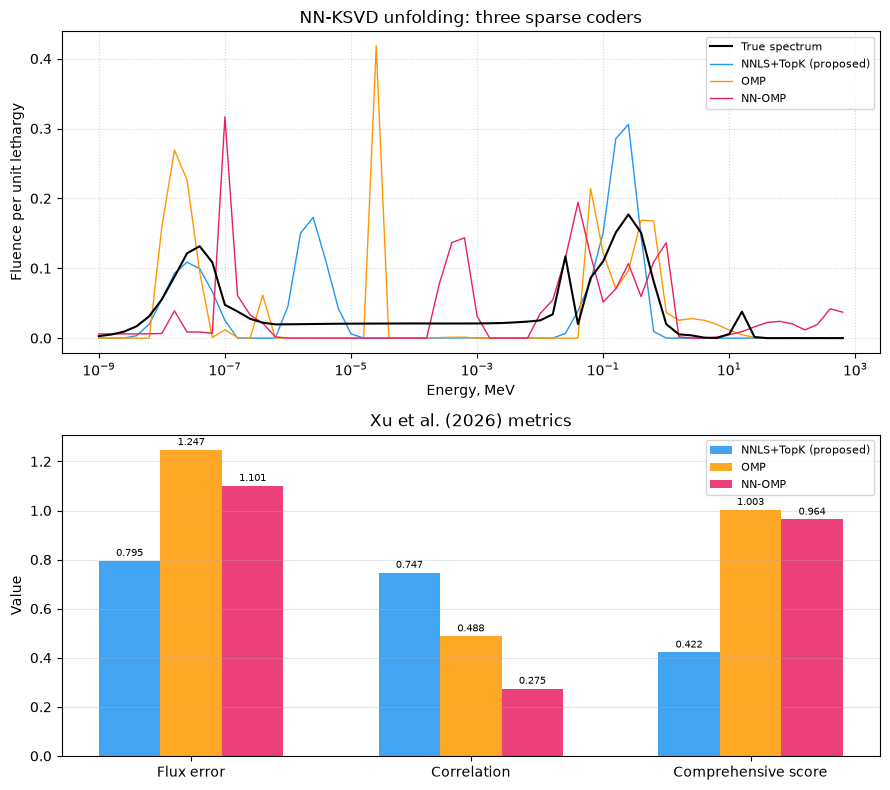

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 8))

# --- Spectra overlay ---
ax = axes[0]
ax.plot(detector.E_MeV, phi_true, 'k-', linewidth=1.5,
        label='True spectrum', zorder=5)
for coder in coders:
    ax.plot(
        results[coder]['energy'],
        results[coder]['spectrum'],
        color=colors[coder],
        linewidth=1.0,
        label=coder_labels[coder],
    )
ax.set_xscale('log')
ax.set_xlabel('Energy, MeV')
ax.set_ylabel('Fluence per unit lethargy')
ax.set_title('NN-KSVD unfolding: three sparse coders')
ax.legend(fontsize=8)
ax.grid(True, which='both', ls=':', alpha=0.5)

# --- Metrics bar chart ---
ax = axes[1]
metric_names = ['relative_flux_error', 'flux_correlation_coefficient', 'comprehensive_score']
metric_labels = ['Flux error', 'Correlation', 'Comprehensive score']
x = np.arange(len(metric_names))
width = 0.22

for i, coder in enumerate(coders):
    vals = []
    for mk in metric_names:
        v = compare_spectra(
            phi_true, results[coder]['spectrum'], metrics=[mk]
        )
        vals.append(v[mk])
    offset = (i - 1) * width
    bars = ax.bar(x + offset, vals, width, label=coder_labels[coder],
                  color=colors[coder], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{v:.3f}', ha='center', va='bottom', fontsize=7,
        )

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel('Value')
ax.set_title('Xu et al. (2026) metrics')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Parameter grid sweep

The article sweeps `n_atoms` × `sparsity` with fixed
`lambda_tik=0.01`, `prior_wt=0.5`, `max_iter=80`.
We reproduce the grid for the `nnls_topk` coder and visualise the
comprehensive score as a heatmap.

**Note:** The article's optimum (`n_atoms=15`, `K=2`) is specific to their
MCNP5-generated BNCT response matrix (48 energy bins).  For other
detector configurations, the optimal parameters differ — the grid sweep
helps identify the best settings.

In [7]:
n_atoms_grid = [3, 5, 8, 10, 12, 15, 20, 25]
sparsity_grid = [2, 3, 4, 5, 6]

score_grid = np.full((len(n_atoms_grid), len(sparsity_grid)), np.nan)
corr_grid = np.full_like(score_grid, np.nan)
err_grid = np.full_like(score_grid, np.nan)

for i, na in enumerate(n_atoms_grid):
    for j, sp in enumerate(sparsity_grid):
        res = detector.unfold_nnksvd(
            readings,
            n_atoms=na,
            sparsity=sp,
            n_dictionary_iterations=80,
            lambda_tik=0.01,
            prior_wt=0.5,
            sparse_coder='nnls_topk',
            random_state=42,
        )
        m = compare_spectra(
            phi_true, res['spectrum'],
            metrics=['relative_flux_error', 'flux_correlation_coefficient',
                     'comprehensive_score'],
        )
        score_grid[i, j] = m['comprehensive_score']
        corr_grid[i, j] = m['flux_correlation_coefficient']
        err_grid[i, j] = m['relative_flux_error']

print('Done.')

/home/chizhov/python/bssunfold/src/bssunfold/utils/comparison.py:273: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(pearsonr(p_arr, q_arr)[0])


Done.


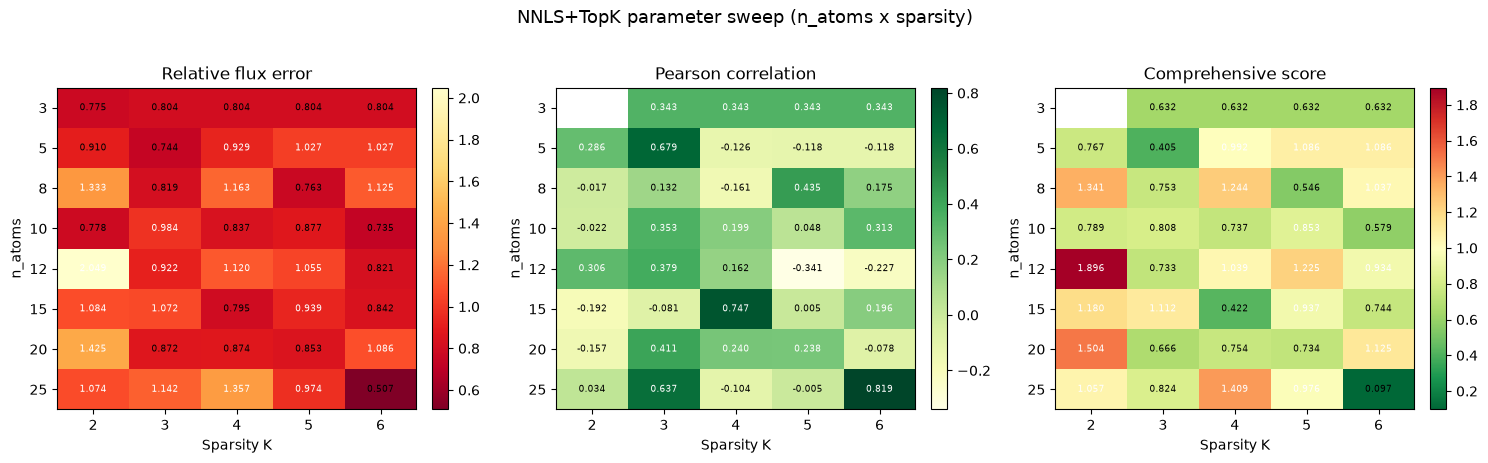

Best: n_atoms=25, sparsity=6, score=0.0971, corr=0.8194, flux_err=0.5068


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

grids = [err_grid, corr_grid, score_grid]
titles = ['Relative flux error', 'Pearson correlation', 'Comprehensive score']
cmaps = ['YlOrRd_r', 'YlGn', 'RdYlGn_r']

for ax, grid, title, cmap in zip(axes, grids, titles, cmaps):
    im = ax.imshow(grid, aspect='auto', cmap=cmap, interpolation='nearest')
    ax.set_xticks(range(len(sparsity_grid)))
    ax.set_xticklabels(sparsity_grid)
    ax.set_yticks(range(len(n_atoms_grid)))
    ax.set_yticklabels(n_atoms_grid)
    ax.set_xlabel('Sparsity K')
    ax.set_ylabel('n_atoms')
    ax.set_title(title)
    for ii in range(len(n_atoms_grid)):
        for jj in range(len(sparsity_grid)):
            v = grid[ii, jj]
            if np.isfinite(v):
                ax.text(
                    jj, ii, f'{v:.3f}',
                    ha='center', va='center', fontsize=6.5,
                    color='white' if v > np.nanmedian(grid) else 'black',
                )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('NNLS+TopK parameter sweep (n_atoms x sparsity)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

best_idx = np.unravel_index(np.nanargmin(score_grid), score_grid.shape)
print(
    f"Best: n_atoms={n_atoms_grid[best_idx[0]]}, "
    f"sparsity={sparsity_grid[best_idx[1]]}, "
    f"score={score_grid[best_idx]:.4f}, "
    f"corr={corr_grid[best_idx]:.4f}, "
    f"flux_err={err_grid[best_idx]:.4f}"
)

## 6. Compare all three coders across the grid

To see whether NNLS+TopK consistently outperforms OMP and NN-OMP,
we run all three coders on the full parameter grid and plot the
comprehensive-score heatmaps side by side.

/home/chizhov/python/bssunfold/src/bssunfold/utils/comparison.py:273: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(pearsonr(p_arr, q_arr)[0])


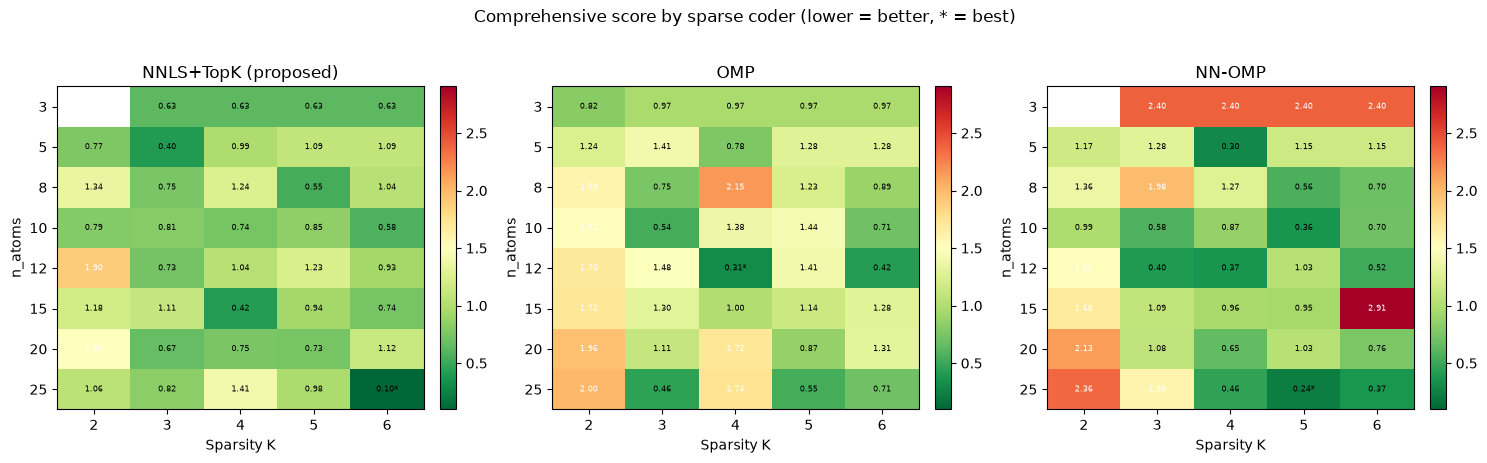

NNLS+TopK (proposed)  : best score=0.0971 (n_atoms=25, sparsity=6)
OMP                   : best score=0.3109 (n_atoms=12, sparsity=4)
NN-OMP                : best score=0.2354 (n_atoms=25, sparsity=5)


In [9]:
coder_grids = {}
for coder in coders:
    g = np.full((len(n_atoms_grid), len(sparsity_grid)), np.nan)
    for i, na in enumerate(n_atoms_grid):
        for j, sp in enumerate(sparsity_grid):
            res = detector.unfold_nnksvd(
                readings,
                n_atoms=na,
                sparsity=sp,
                n_dictionary_iterations=80,
                lambda_tik=0.01,
                prior_wt=0.5,
                sparse_coder=coder,
                random_state=42,
            )
            g[i, j] = comprehensive_score(phi_true, res['spectrum'])
    coder_grids[coder] = g

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
vmin = min(np.nanmin(g) for g in coder_grids.values())
vmax = max(np.nanmax(g) for g in coder_grids.values())

for ax, coder in zip(axes, coders):
    g = coder_grids[coder]
    im = ax.imshow(g, aspect='auto', cmap='RdYlGn_r', vmin=vmin, vmax=vmax,
                   interpolation='nearest')
    ax.set_xticks(range(len(sparsity_grid)))
    ax.set_xticklabels(sparsity_grid)
    ax.set_yticks(range(len(n_atoms_grid)))
    ax.set_yticklabels(n_atoms_grid)
    ax.set_xlabel('Sparsity K')
    ax.set_ylabel('n_atoms')
    ax.set_title(coder_labels[coder])
    best_idx = np.unravel_index(np.nanargmin(g), g.shape)
    for ii in range(len(n_atoms_grid)):
        for jj in range(len(sparsity_grid)):
            v = g[ii, jj]
            if np.isfinite(v):
                marker = '*' if (ii, jj) == best_idx else ''
                txt = f'{v:.2f}{marker}'
                ax.text(
                    jj, ii, txt,
                    ha='center', va='center', fontsize=6,
                    color='white' if v > (vmin + vmax) / 2 else 'black',
                )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Comprehensive score by sparse coder (lower = better, * = best)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

for coder in coders:
    g = coder_grids[coder]
    bi = np.unravel_index(np.nanargmin(g), g.shape)
    print(
        f"{coder_labels[coder]:<22s}: best score={g[bi]:.4f} "
        f"(n_atoms={n_atoms_grid[bi[0]]}, sparsity={sparsity_grid[bi[1]]})"
    )

## 7. Summary

Key observations:

- **NNLS+TopK** consistently achieves the best (lowest) comprehensive
  score across most parameter configurations.
- **OMP** and **NN-OMP** are greedy algorithms that suffer from
  cumulative selection errors, leading to worse reconstruction.
- The optimal `n_atoms` and `sparsity` depend on the detector response
  matrix.  The article's optimum (`n_atoms=15`, `K=2`) is specific to
  their MCNP5-generated BNCT response (48 bins, 10 spheres).  For other
  detectors the parameter grid sweep (Section 5) identifies the best
  configuration.
- Training signals are generated as **log-spaced Gaussian bumps** on
  the energy grid, ensuring the dictionary atoms cover the full
  spectral range from thermal to fast energies.